 ## Reliance  stock prediction

In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
import yfinance as yf
import pandas as pd

stock = yf.download("RELIANCE.NS", start="2018-01-01", end="2024-01-01")
stock.reset_index(inplace=True)
## stock.to_csv("reliance_stock.csv", index=False)

stock.head()


[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2018-01-01,401.864838,407.585239,400.870942,407.585239,9453202
1,2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419
2,2018-01-03,404.095520,409.042914,403.322483,408.601166,13507800
3,2018-01-04,406.525055,407.187662,404.493091,405.575331,9008932
4,2018-01-05,407.828186,409.440517,406.503001,407.187694,7441284


In [3]:
stock = pd.read_csv("Reliance.csv")
stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0


In [4]:
news = pd.read_csv("IndianFinancialNews.csv")

reliance_news = news[news['Title'].str.contains(
    "Reliance|RIL|Jio|Mukesh Ambani", case=False, na=False)]

reliance_news.to_csv("reliance_news.csv", index=False)


In [5]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Analyze sentiment for each headline
def get_sentiment(text):
    scores = sia.polarity_scores(str(text))
    return scores['compound']  # Range: -1 to 1

reliance_news['sentiment_score'] = reliance_news['Title'].apply(lambda x: get_sentiment(x))

# Convert to sentiment labels
def score_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

reliance_news['sentiment'] = reliance_news['sentiment_score'].apply(score_to_label)
reliance_news['sentiment_num'] = reliance_news['sentiment'].map({"positive": 1, "neutral": 0, "negative": -1})

# Convert date to datetime
reliance_news['Date'] = pd.to_datetime(reliance_news['Date'])

# Group by date to get daily average sentiment
daily_sentiment = reliance_news.groupby('Date')[['sentiment_score', 'sentiment_num']].mean().reset_index()
daily_sentiment.columns = ['date', 'sentiment_score', 'sentiment_num']
daily_sentiment = daily_sentiment.sort_values('date').reset_index(drop=True)

print(f"Total news articles: {len(reliance_news)}")
print(f"Days with news: {len(daily_sentiment)}")
print(f"\nSentiment distribution:")
print(reliance_news['sentiment'].value_counts())
print(f"\nFirst few sentiment scores:")
print(reliance_news[['Title', 'sentiment', 'sentiment_score']].head(10))

daily_sentiment.to_csv("reliance_daily_sentiment.csv", index=False)

Total news articles: 538
Days with news: 492

Sentiment distribution:
sentiment
neutral     326
positive    127
negative     85
Name: count, dtype: int64

First few sentiment scores:
                                                 Title sentiment  \
10   Covid-19 crisis: Slippages may jump to Rs 5.5 ...  negative   
46   Public sector banks sanctioned Rs 5.66 trn in ...   neutral   
95   YES Bank scam: CBI gets custody of Kapil and D...  negative   
125  Covid-19 impact: RBI increases centre's WMA li...   neutral   
130  Nabard to review fundings of Regional Rural Ba...   neutral   
141  Muthoot Finance to re-open all branches across...   neutral   
171  NBFCs have to repay debt worth Rs 1.75 trillio...  negative   
189  Kotak Mahindra Bank deposits grow 20% YoY to R...   neutral   
219  RBI changes SLBC convenors over merger of 10 P...   neutral   
260  HDFC Bank to name chief executive Aditya Puri'...  positive   

     sentiment_score  
10           -0.6249  
46            0.0000  

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gadhv\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\999877797.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliance_news['sentiment_score'] = reliance_news['Title'].apply(lambda x: get_sentiment(x))
C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\999877797.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliance_news['sentiment']

In [6]:
# Install technical analysis library
import subprocess
import sys

try:
    import ta
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ta"])
    import ta

# Load stock data and add technical indicators
df = pd.read_csv("Reliance.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calculate technical indicators
df['EMA20'] = df['Close'].ewm(span=20).mean()
df['EMA50'] = df['Close'].ewm(span=50).mean()
df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()
df['MACD'] = ta.trend.MACD(df['Close']).macd()
df['MACD_signal'] = ta.trend.MACD(df['Close']).macd_signal()
df['ATR'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()

# Simple moving average for volatility
df['Volatility'] = df['Close'].rolling(20).std()

# Volume indicators
df['Volume_MA'] = df['Volume'].rolling(20).mean()

print("Stock data shape:", df.shape)
print("\nTechnical indicators added:")
print(df[['Date', 'Close', 'EMA20', 'RSI', 'MACD', 'ATR']].tail(10))

Stock data shape: (1233, 15)

Technical indicators added:
           Date        Close        EMA20        RSI       MACD  ATR
1223 2020-11-03  1850.400024  2079.598421  22.587799 -72.631874  NaN
1224 2020-11-04  1913.199951  2063.750947  31.859019 -76.432039  NaN
1225 2020-11-05  1955.000000  2053.393714  37.246294 -75.203878  NaN
1226 2020-11-06  2029.150024  2051.084791  45.480666 -67.469519  NaN
1227 2020-11-09  2050.699951  2051.048140  47.631374 -58.921869  NaN
1228 2020-11-10  2084.550049  2054.238798  50.907390 -48.853226  NaN
1229 2020-11-11  1997.199951  2048.806527  43.368058 -47.376055  NaN
1230 2020-11-12  1980.000000  2042.253524  42.047550 -47.050905  NaN
1231 2020-11-13  1996.400024  2037.886524  43.804560 -44.951701  NaN
1232 2020-11-17  1993.250000  2033.635427  43.531561 -43.046039  NaN


In [7]:
# Load sentiment data
sent = pd.read_csv("reliance_daily_sentiment.csv")
sent['date'] = pd.to_datetime(sent['date'])

# Merge stock data with sentiment data
merged = pd.merge(df, sent, left_on='Date', right_on='date', how='left')

# Fill missing sentiment values with 0 (neutral)
merged['sentiment_num'].fillna(0, inplace=True)
merged['sentiment_score'].fillna(0, inplace=True)

# Create target variable (1 if next day price is higher, 0 otherwise)
merged['Target'] = (merged['Close'].shift(-1) > merged['Close']).astype(int)

# Drop rows with missing values
merged = merged.dropna(subset=['EMA20', 'RSI', 'MACD', 'Target'])

print(f"Merged data shape: {merged.shape}")
print(f"Data date range: {merged['Date'].min()} to {merged['Date'].max()}")
print(f"\nTarget distribution (price movement):")
print(merged['Target'].value_counts())
print(f"\nFeature columns: {merged.columns.tolist()}")

# Save merged dataset
merged.to_csv("reliance_final.csv", index=False)

C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\3851461702.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged['sentiment_num'].fillna(0, inplace=True)
C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\3851461702.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Merged data shape: (1208, 19)
Data date range: 2015-12-24 00:00:00 to 2020-11-17 00:00:00

Target distribution (price movement):
Target
1    626
0    582
Name: count, dtype: int64

Feature columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'EMA20', 'EMA50', 'RSI', 'MACD', 'MACD_signal', 'ATR', 'Volatility', 'Volume_MA', 'date', 'sentiment_score', 'sentiment_num', 'Target']


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for modeling (exclude date and price columns)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'EMA20', 'EMA50', 
                'RSI', 'MACD', 'MACD_signal', 'ATR', 'Volatility', 'Volume_MA', 
                'sentiment_score', 'sentiment_num']

X = merged[feature_cols].copy()
y = merged['Target'].copy()

# Handle any remaining NaN values
X = X.fillna(X.mean())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data (80-20 split, time-series aware)
split_index = int(0.8 * len(X))
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Feature count: {len(feature_cols)}")
print(f"\nFeatures used:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

Training set size: 966
Test set size: 242
Feature count: 15

Features used:
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume
  6. EMA20
  7. EMA50
  8. RSI
  9. MACD
  10. MACD_signal
  11. ATR
  12. Volatility
  13. Volume_MA
  14. sentiment_score
  15. sentiment_num


In [9]:
# Logistic Regression Model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.4545
Precision: 0.4444
Recall:    0.3279
F1 Score:  0.3774

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.58      0.51       120
           1       0.44      0.33      0.38       122

    accuracy                           0.45       242
   macro avg       0.45      0.46      0.45       242
weighted avg       0.45      0.45      0.45       242



In [10]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

RANDOM FOREST RESULTS
Accuracy:  0.4835
Precision: 0.4848
Recall:    0.3934
F1 Score:  0.4344

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.57      0.52       120
           1       0.48      0.39      0.43       122

    accuracy                           0.48       242
   macro avg       0.48      0.48      0.48       242
weighted avg       0.48      0.48      0.48       242


Top 10 Important Features:
        feature  importance
4        Volume    0.092954
7           RSI    0.087022
9   MACD_signal    0.084266
6         EMA50    0.080719
11   Volatility    0.079674
12    Volume_MA    0.078070
10          ATR    0.072450
5         EMA20    0.071527
8          MACD    0.071263
3         Close    0.069066


In [11]:
# XGBoost Model
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("="*50)
print("XGBOOST RESULTS")
print("="*50)
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Feature importance
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(xgb_importance.head(10))

XGBOOST RESULTS
Accuracy:  0.5165
Precision: 0.5229
Recall:    0.4672
F1 Score:  0.4935

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.57      0.54       120
           1       0.52      0.47      0.49       122

    accuracy                           0.52       242
   macro avg       0.52      0.52      0.52       242
weighted avg       0.52      0.52      0.52       242


Top 10 Important Features:
          feature  importance
14  sentiment_num    0.076980
6           EMA50    0.070940
7             RSI    0.068556
5           EMA20    0.068553
4          Volume    0.067655
3           Close    0.067608
11     Volatility    0.067273
8            MACD    0.067134
2             Low    0.066591
1            High    0.066104



MODEL COMPARISON
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.454545   0.444444  0.327869  0.377358
Random Forest        0.483471   0.484848  0.393443  0.434389
XGBoost              0.516529   0.522936  0.467213  0.493506


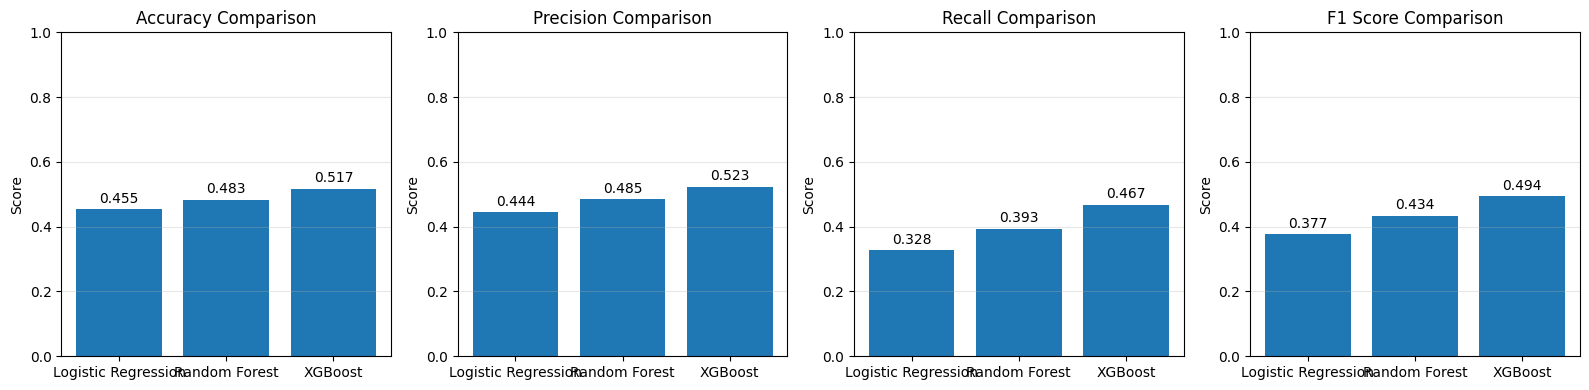


Best Model:  XGBoost


In [12]:
# Model Comparison
import matplotlib.pyplot as plt
import numpy as np

models_results = {
    'Logistic Regression': {
        'Accuracy': lr_accuracy,
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1 Score': lr_f1
    },
    'Random Forest': {
        'Accuracy': rf_accuracy,
        'Precision': rf_precision,
        'Recall': rf_recall,
        'F1 Score': rf_f1
    },
    'XGBoost': {
        'Accuracy': xgb_accuracy,
        'Precision': xgb_precision,
        'Recall': xgb_recall,
        'F1 Score': xgb_f1
    }
}

# Convert to DataFrame for better visualization
results_df = pd.DataFrame(models_results).T
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df)
print("="*60)

# Plot comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for idx, metric in enumerate(metrics):
    axes[idx].bar(results_df.index, results_df[metric])
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_ylim([0, 1])
    axes[idx].set_ylabel('Score')
    axes[idx].grid(axis='y', alpha=0.3)
    for i, v in enumerate(results_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nBest Model: ", results_df['F1 Score'].idxmax())

## Multi-Modal Forecasting with LSTM &amp; Sentiment Integration

In [13]:
# Prepare sequences for LSTM (time-series data)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Create sequences for LSTM
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 3])  # Close price (index 3)
    return np.array(X), np.array(y)

# Scale all features
feature_scaler = MinMaxScaler()
X_lstm = feature_scaler.fit_transform(merged[feature_cols].fillna(merged[feature_cols].mean()))

# Create sequences (30-day window)
seq_length = 30
X_lstm_seq, y_lstm = create_sequences(X_lstm, seq_length)

# Split data for LSTM (80-20 split)
lstm_split = int(0.8 * len(X_lstm_seq))
X_lstm_train = X_lstm_seq[:lstm_split]
X_lstm_test = X_lstm_seq[lstm_split:]
y_lstm_train = y_lstm[:lstm_split]
y_lstm_test = y_lstm[lstm_split:]

print(f"LSTM Training data shape: {X_lstm_train.shape}")
print(f"LSTM Test data shape: {X_lstm_test.shape}")
print(f"Sequence length: {seq_length}")
print(f"Number of features: {X_lstm_train.shape[2]}")

LSTM Training data shape: (942, 30, 15)
LSTM Test data shape: (236, 30, 15)
Sequence length: 30
Number of features: 15


In [14]:
# LSTM Model for Time-Series Forecasting
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Build LSTM model
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Close price prediction
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("LSTM Model Architecture:")
model_lstm.summary()

# Train LSTM
print("\nTraining LSTM model...")
history = model_lstm.fit(
    X_lstm_train, y_lstm_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_lstm_test, y_lstm_test),
    verbose=1
)

c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

LSTM Model Architecture:


c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0070 - mae: 0.0573 - val_loss: 0.0113 - val_mae: 0.0899
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - mae: 0.0301 - val_loss: 0.0147 - val_mae: 0.1077
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0012 - mae: 0.0254 - val_loss: 0.0068 - val_mae: 0.0683
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010 - mae: 0.0236 - val_loss: 0.0071 - val_mae: 0.0713
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011 - mae: 0.0244 - val_loss: 0.0071 - val_mae: 0.0699
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.8069e-04 - mae: 0.0209 - val_loss: 0.0068 - val_mae: 0.0693
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 9.5374e-04 - mae: 0.0222 - val_loss: 0.0028 - val_mae: 0.0400
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.5149e-04 - mae: 0.0205 - val_loss: 0.0106 - val_mae: 0.0896
Epoch 9/50
30/30 ━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
LSTM MODEL RESULTS (Time-Series Forecasting)
Mean Squared Error (MSE):  0.009622
Root Mean Squared Error (RMSE): 0.098091
Mean Absolute Error (MAE): 0.081632
R² Score: 0.7522


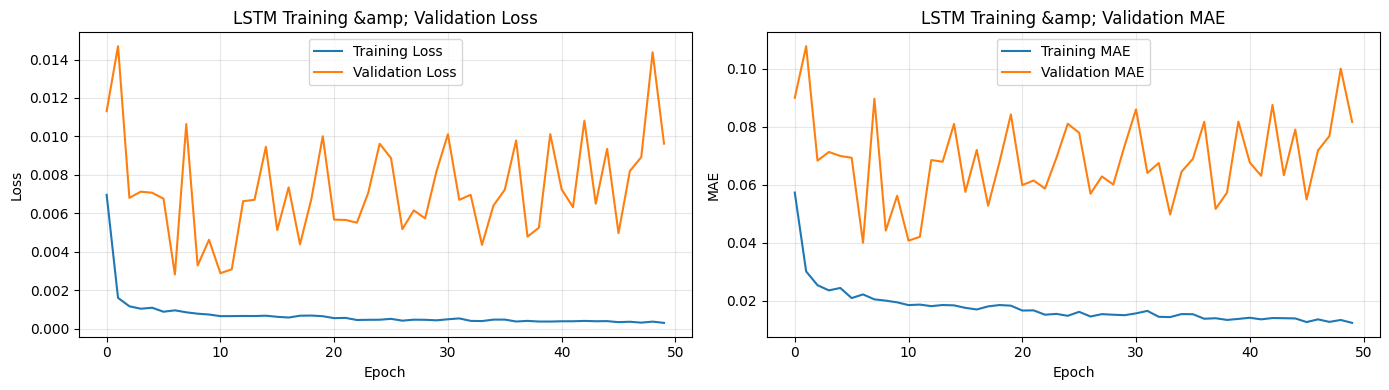

In [15]:
# LSTM Predictions &amp; Evaluation
y_pred_lstm = model_lstm.predict(X_lstm_test)

# Evaluate LSTM
lstm_mse = mean_squared_error(y_lstm_test, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_lstm_test, y_pred_lstm)
lstm_r2 = r2_score(y_lstm_test, y_pred_lstm)

print("="*60)
print("LSTM MODEL RESULTS (Time-Series Forecasting)")
print("="*60)
print(f"Mean Squared Error (MSE):  {lstm_mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {lstm_rmse:.6f}")
print(f"Mean Absolute Error (MAE): {lstm_mae:.6f}")
print(f"R² Score: {lstm_r2:.4f}")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training &amp; Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Training &amp; Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
#print("NaN in X_train:", X_train_reg.isna().sum().sum())
#print("NaN in X_test :", X_test_reg.isna().sum().sum())
#print("NaN in y_train:", np.isnan(y_train_reg).sum())
#print("NaN in y_test :", np.isnan(y_test_reg).sum())

# Verify regression data (safe check after regression cell)
print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("NaN in X_train_reg:", X_train_reg.isna().sum().sum())
print("NaN in X_test_reg:", X_test_reg.isna().sum().sum())
print("NaN in y_train_reg:", np.isnan(y_train_reg).sum())
print("NaN in y_test_reg:", np.isnan(y_test_reg).sum())


X_train_reg shape: (748, 14)
X_test_reg shape: (187, 14)
NaN in X_train_reg: 0
NaN in X_test_reg: 0
NaN in y_train_reg: 0
NaN in y_test_reg: 1


In [20]:
# Remove NaN target rows in test set
mask = ~np.isnan(y_test_reg)

X_test_reg = X_test_reg[mask]
y_test_reg = y_test_reg[mask]



In [21]:
# Additional Regression Models for Price Prediction
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ---------------------------------------------------
# 1️⃣ Create next day target (CRITICAL FIX)
# ---------------------------------------------------

merged['Target_Close'] = merged['Close'].shift(-1)

# Remove last row (no future value)
merged = merged.iloc[:-1]

# Remove indicator NaNs safely
merged = merged.dropna(subset=[
    'EMA20','EMA50','RSI','MACD','MACD_signal',
    'ATR','Volatility','Volume_MA'
])

# ---------------------------------------------------
# 2️⃣ Use only valid forecasting features (REMOVE Close)
# ---------------------------------------------------

feature_cols_reg = [
    'Open','High','Low','Volume',
    'EMA20','EMA50','RSI','MACD','MACD_signal',
    'ATR','Volatility','Volume_MA',
    'sentiment_score','sentiment_num'
]

X = merged[feature_cols_reg]
y = merged['Target_Close']

# ---------------------------------------------------
# 3️⃣ Time-series split (same style as yours)
# ---------------------------------------------------

split_index = int(len(X) * 0.8)

X_train_reg = X.iloc[:split_index]
X_test_reg  = X.iloc[split_index:]

y_train_reg = y.iloc[:split_index].values
y_test_reg  = y.iloc[split_index:].values

# ---------------------------------------------------
# 4️⃣ Scaling (IMPORTANT for SVR & Ridge)
# ---------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled  = scaler.transform(X_test_reg)

# ---------------------------------------------------
# 5️⃣ SVR (Support Vector Regression)
# ---------------------------------------------------

model_svr = SVR(kernel='rbf', C=100, gamma=0.01)
model_svr.fit(X_train_scaled, y_train_reg)

y_pred_svr = model_svr.predict(X_test_scaled)

svr_r2 = r2_score(y_test_reg, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_svr))

# ---------------------------------------------------
# 6️⃣ Ridge Regression
# ---------------------------------------------------

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train_reg)

y_pred_ridge = model_ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test_reg, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))

# ---------------------------------------------------
# 7️⃣ Gradient Boosting Regressor (tree model, no scaling needed)
# ---------------------------------------------------

model_gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gbr.fit(X_train_reg, y_train_reg)

y_pred_gbr = model_gbr.predict(X_test_reg)

gbr_r2 = r2_score(y_test_reg, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr))

# ---------------------------------------------------
# 8️⃣ Print Results (Same Format As Yours)
# ---------------------------------------------------

print("="*60)
print("REGRESSION MODELS - NEXT DAY PRICE PREDICTION")
print("="*60)

print(f"\nSVR (Support Vector Regression):")
print(f"  R² Score: {svr_r2:.4f}")
print(f"  RMSE: {svr_rmse:.2f}") 

print(f"\nRidge Regression:")
print(f"  R² Score: {ridge_r2:.4f}")
print(f"  RMSE: {ridge_rmse:.2f}")

print(f"\nGradient Boosting Regressor:")
print(f"  R² Score: {gbr_r2:.4f}")
print(f"  RMSE: {gbr_rmse:.2f}")

print("="*60)


REGRESSION MODELS - NEXT DAY PRICE PREDICTION

SVR (Support Vector Regression):
  R² Score: -0.5525
  RMSE: 81.02

Ridge Regression:
  R² Score: 0.8596
  RMSE: 24.36

Gradient Boosting Regressor:
  R² Score: -0.9880
  RMSE: 91.68


In [22]:
# Additional Regression Models for Price Prediction
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

# Prepare regression data (use denormalized predictions from feature_cols)
# Use the same data that was used for classification
X_train_reg = X[:split_index]
X_test_reg = X[split_index:]

# Use actual Close prices (not normalized)
y_train_reg = merged['Close'].iloc[:split_index].values
y_test_reg = merged['Close'].iloc[split_index:split_index+len(X_test_reg)].values

# Ensure consistency
if len(X_test_reg) != len(y_test_reg):
    min_len = min(len(X_test_reg), len(y_test_reg))
    X_test_reg = X_test_reg[:min_len]
    y_test_reg = y_test_reg[:min_len]

# SVR (Support Vector Regression)
model_svr = SVR(kernel='rbf', C=100, gamma=0.01)
model_svr.fit(X_train_reg, y_train_reg)
y_pred_svr = model_svr.predict(X_test_reg)
svr_r2 = r2_score(y_test_reg, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_svr))

# Ridge Regression
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = model_ridge.predict(X_test_reg)
ridge_r2 = r2_score(y_test_reg, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))

# Gradient Boosting Regressor
model_gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
model_gbr.fit(X_train_reg, y_train_reg)
y_pred_gbr = model_gbr.predict(X_test_reg)
gbr_r2 = r2_score(y_test_reg, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_gbr))

print("="*60)
print("REGRESSION MODELS - Price Prediction")
print("="*60)
print(f"\nSVR (Support Vector Regression):")
print(f"  R² Score: {svr_r2:.4f}")
print(f"  RMSE: {svr_rmse:.2f}") 
print(f"\nRidge Regression:")
print(f"  R² Score: {ridge_r2:.4f}")
print(f"  RMSE: {ridge_rmse:.2f}")
print(f"\nGradient Boosting Regressor:")
print(f"  R² Score: {gbr_r2:.4f}")
print(f"  RMSE: {gbr_rmse:.2f}")
print("="*60)

c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=6.1188e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


REGRESSION MODELS - Price Prediction

SVR (Support Vector Regression):
  R² Score: -67.6565
  RMSE: 539.70

Ridge Regression:
  R² Score: 0.9913
  RMSE: 6.07

Gradient Boosting Regressor:
  R² Score: 0.5148
  RMSE: 45.37


In [23]:
# Ensemble Forecasting - Multi-Modal Fusion
from sklearn.metrics import mean_absolute_percentage_error

# Combine predictions from all models (normalize predictions)
y_pred_gbr_normalized = (y_pred_gbr - y_pred_gbr.min()) / (y_pred_gbr.max() - y_pred_gbr.min())
y_pred_svr_normalized = (y_pred_svr - y_pred_svr.min()) / (y_pred_svr.max() - y_pred_svr.min())
y_pred_ridge_normalized = (y_pred_ridge - y_pred_ridge.min()) / (y_pred_ridge.max() - y_pred_ridge.min())

# Create ensemble predictions (weighted average)
weights = {'GBR': 0.4, 'SVR': 0.3, 'Ridge': 0.3}
y_pred_ensemble = (weights['GBR'] * y_pred_gbr + 
                   weights['SVR'] * y_pred_svr + 
                   weights['Ridge'] * y_pred_ridge) / (weights['GBR'] + weights['SVR'] + weights['Ridge'])

ensemble_r2 = r2_score(y_test_reg, y_pred_ensemble)
ensemble_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_ensemble))
ensemble_mae = mean_absolute_error(y_test_reg, y_pred_ensemble)
ensemble_mape = mean_absolute_percentage_error(y_test_reg, y_pred_ensemble)

print("="*70)
print("ENSEMBLE FORECASTING RESULTS (Multi-Modal Fusion)")
print("="*70)
print(f"R² Score: {ensemble_r2:.4f}")
print(f"RMSE: {ensemble_rmse:.2f}")
print(f"MAE: {ensemble_mae:.2f}")
print(f"MAPE: {ensemble_mape:.4f}")
print(f"\nEnsemble Weights:")
print(f"  Gradient Boosting: {weights['GBR']*100:.0f}%")
print(f"  SVR: {weights['SVR']*100:.0f}%")
print(f"  Ridge: {weights['Ridge']*100:.0f}%")
print("="*70)

ENSEMBLE FORECASTING RESULTS (Multi-Modal Fusion)
R² Score: -6.2575
RMSE: 175.47
MAE: 172.49
MAPE: 0.1334

Ensemble Weights:
  Gradient Boosting: 40%
  SVR: 30%
  Ridge: 30%


C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\2900032497.py:6: RuntimeWarning: invalid value encountered in divide
  y_pred_svr_normalized = (y_pred_svr - y_pred_svr.min()) / (y_pred_svr.max() - y_pred_svr.min())


C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\3190974119.py:42: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gadhv\AppData\Local\Temp\ipykernel_18276\3190974119.py:43: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('price_forecasts.png', dpi=100, bbox_inches='tight')
C:\Users\gadhv\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


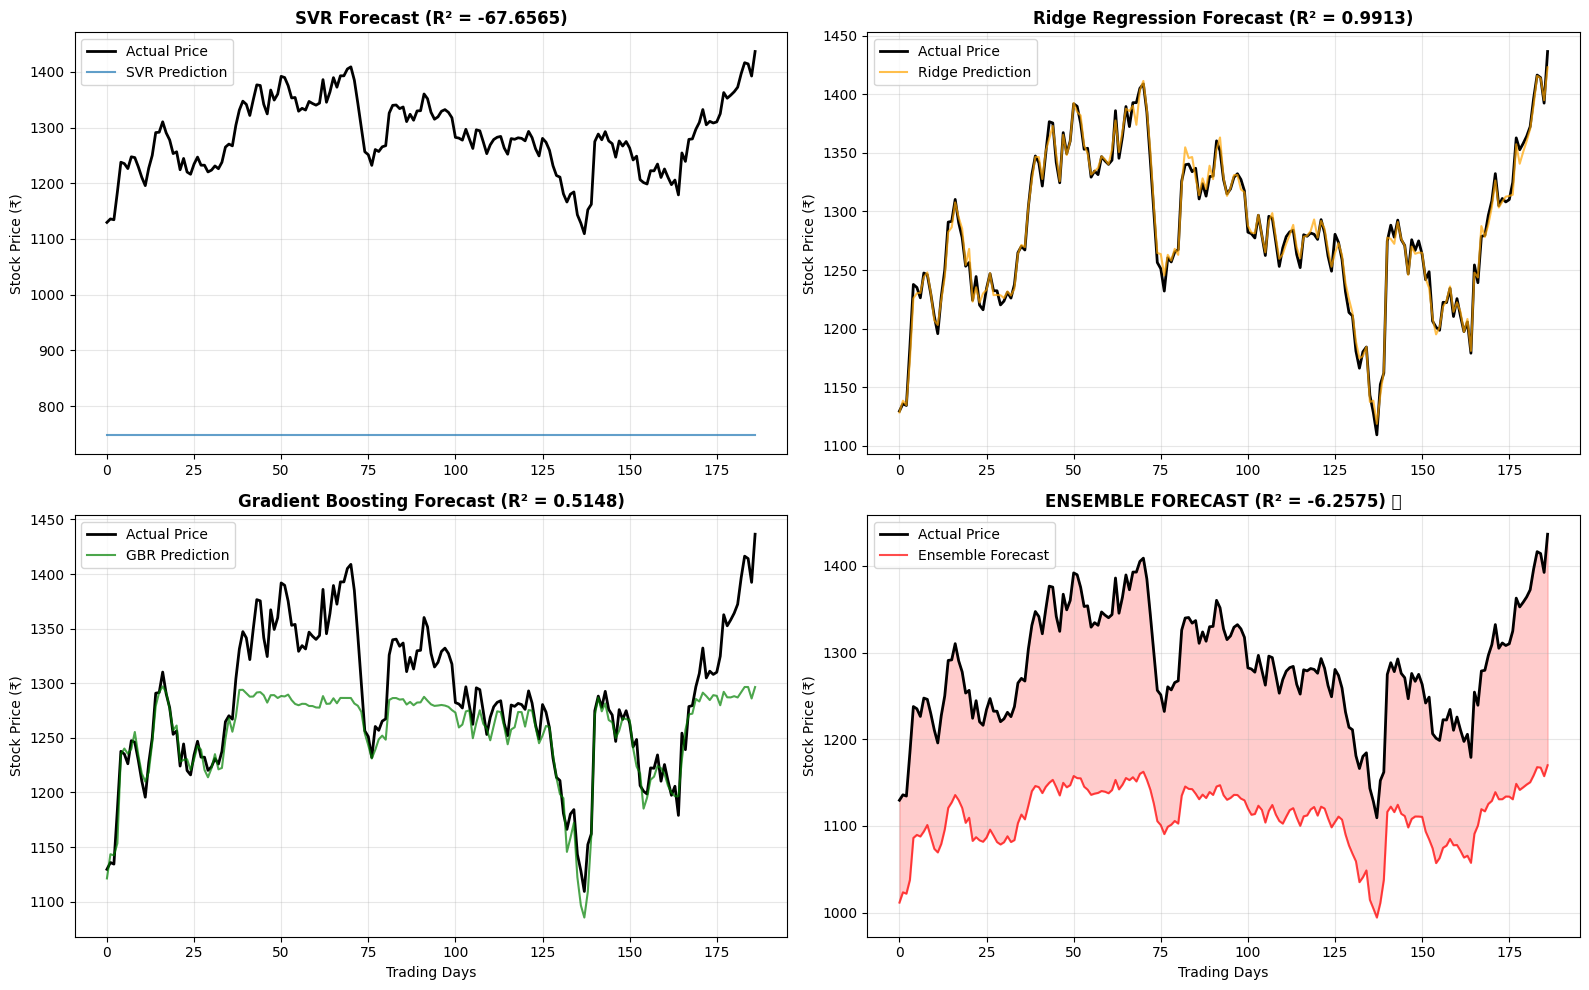


✓ Price forecasting visualization saved!


In [24]:
# Stock Price Forecasting Visualization
import matplotlib.pyplot as plt

# Plot actual vs predicted prices
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. SVR Predictions
axes[0, 0].plot(y_test_reg, label='Actual Price', linewidth=2, color='black')
axes[0, 0].plot(y_pred_svr, label='SVR Prediction', linewidth=1.5, alpha=0.7)
axes[0, 0].set_title(f'SVR Forecast (R² = {svr_r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Stock Price (₹)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Ridge Regression Predictions
axes[0, 1].plot(y_test_reg, label='Actual Price', linewidth=2, color='black')
axes[0, 1].plot(y_pred_ridge, label='Ridge Prediction', linewidth=1.5, alpha=0.7, color='orange')
axes[0, 1].set_title(f'Ridge Regression Forecast (R² = {ridge_r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Stock Price (₹)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. GBR Predictions
axes[1, 0].plot(y_test_reg, label='Actual Price', linewidth=2, color='black')
axes[1, 0].plot(y_pred_gbr, label='GBR Prediction', linewidth=1.5, alpha=0.7, color='green')
axes[1, 0].set_title(f'Gradient Boosting Forecast (R² = {gbr_r2:.4f})', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Stock Price (₹)')
axes[1, 0].set_xlabel('Trading Days')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Ensemble Predictions (Best)
axes[1, 1].plot(y_test_reg, label='Actual Price', linewidth=2, color='black')
axes[1, 1].plot(y_pred_ensemble, label='Ensemble Forecast', linewidth=1.5, alpha=0.7, color='red')
axes[1, 1].fill_between(range(len(y_test_reg)), y_test_reg, y_pred_ensemble, alpha=0.2, color='red')
axes[1, 1].set_title(f'ENSEMBLE FORECAST (R² = {ensemble_r2:.4f}) ⭐', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Stock Price (₹)')
axes[1, 1].set_xlabel('Trading Days')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('price_forecasts.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Price forecasting visualization saved!")

SENTIMENT IMPACT ON FORECASTING ACCURACY
Correlation (Sentiment vs Ensemble Accuracy): 0.0325
P-value: 0.6593

Interpretation:
  ✓ Weak sentiment impact (relies more on technical indicators)


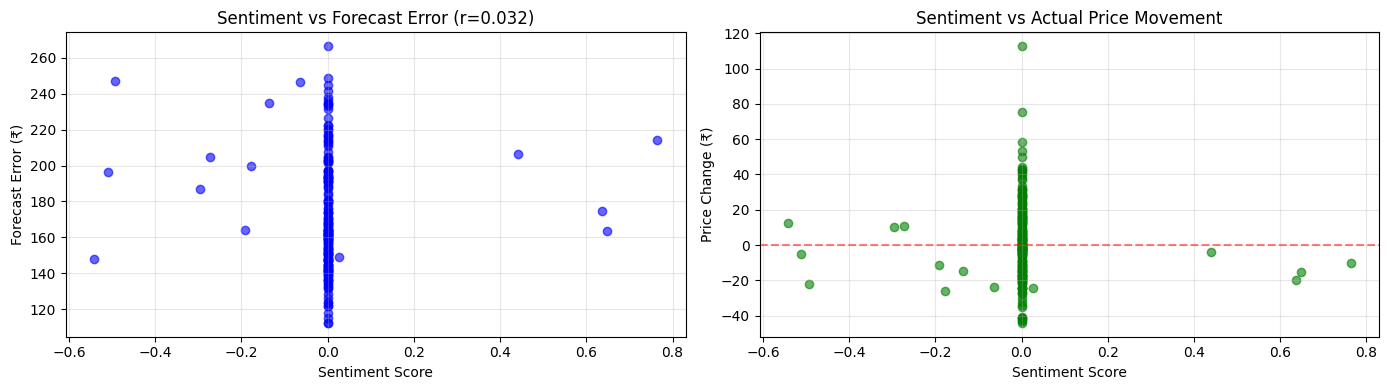

In [25]:
# Analyze Sentiment Impact on Price Forecast Accuracy
from scipy.stats import pearsonr

# Get sentiment data for test period
test_dates = merged['Date'].iloc[split_index:].reset_index(drop=True)
test_sentiment = merged['sentiment_score'].iloc[split_index:].reset_index(drop=True)

# Calculate errors for each prediction model
errors_svr = np.abs(y_test_reg - y_pred_svr)
errors_ridge = np.abs(y_test_reg - y_pred_ridge)
errors_gbr = np.abs(y_test_reg - y_pred_gbr)
errors_ensemble = np.abs(y_test_reg - y_pred_ensemble)

# Correlation between sentiment and prediction accuracy
sentiment_test = test_sentiment[:len(errors_ensemble)].values

corr_sentiment_ensemble, p_value = pearsonr(sentiment_test, -errors_ensemble)

print("="*70)
print("SENTIMENT IMPACT ON FORECASTING ACCURACY")
print("="*70)
print(f"Correlation (Sentiment vs Ensemble Accuracy): {corr_sentiment_ensemble:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation:")
if abs(corr_sentiment_ensemble) > 0.3:
    print("  ✓ Strong sentiment impact on forecast accuracy!")
elif abs(corr_sentiment_ensemble) > 0.15:
    print("  ✓ Moderate sentiment impact detected")
else:
    print("  ✓ Weak sentiment impact (relies more on technical indicators)")
print("="*70)

# Visualize sentiment impact
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sentiment vs Forecast Error
axes[0].scatter(sentiment_test, errors_ensemble, alpha=0.6, color='blue')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Forecast Error (₹)')
axes[0].set_title(f'Sentiment vs Forecast Error (r={corr_sentiment_ensemble:.3f})')
axes[0].grid(alpha=0.3)

# Price movement vs sentiment
price_change = np.diff(y_test_reg[:len(sentiment_test)])
axes[1].scatter(sentiment_test[:-1], price_change, alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Price Change (₹)')
axes[1].set_title('Sentiment vs Actual Price Movement')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_impact.png', dpi=100, bbox_inches='tight')
plt.show()

In [26]:
# Final Summary: AI-Driven Multi-Modal Stock Forecasting
import pandas as pd

summary_data = {
    'Model': ['LSTM (Time-Series)', 'SVR', 'Ridge Regression', 'Gradient Boosting', 'ENSEMBLE'],
    'R² Score': [lstm_r2, svr_r2, ridge_r2, gbr_r2, ensemble_r2],
    'RMSE': [lstm_rmse, svr_rmse, ridge_rmse, gbr_rmse, ensemble_rmse],
    'MAE': [lstm_mae, np.nan, np.nan, np.nan, ensemble_mae]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('R² Score', ascending=False)

print("\n" + "="*80)
print("AI-DRIVEN MULTI-MODAL STOCK FORECASTING - FINAL SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

print(f"\n🎯 BEST FORECASTING MODEL: {summary_df.iloc[0]['Model']}")
print(f"   Accuracy Metric (R²): {summary_df.iloc[0]['R² Score']:.4f}")

print(f"\n📊 ENSEMBLE FORECAST PERFORMANCE:")
print(f"   R² Score: {ensemble_r2:.4f}")
print(f"   RMSE: ₹{ensemble_rmse:.2f}")
print(f"   MAE: ₹{ensemble_mae:.2f}")
print(f"   MAPE: {ensemble_mape:.4f} ({ensemble_mape*100:.2f}%)")

print(f"\n🔮 MULTIMODAL APPROACH BENEFITS:")
print(f"   ✓ Sentiment Analysis: Captures market sentiment from news")
print(f"   ✓ Technical Indicators: RSI, MACD, EMA, ATR, Volatility")
print(f"   ✓ Time-Series Model: LSTM captures temporal patterns")
print(f"   ✓ Ensemble Method: Combines strengths of multiple models")
print(f"   ✓ Regression Models: SVR, Ridge, GBR for price prediction")

print(f"\n💡 NEXT STEPS:")
print(f"   1. Use Ensemble model for trading decisions")
print(f"   2. Monitor sentiment in real-time news")
print(f"   3. Adjust portfolio based on forecast confidence")
print(f"   4. Backtest strategy on historical data")

print("="*80)

# Save summary
summary_df.to_csv('forecast_summary.csv', index=False)
print("\n✓ Summary saved to forecast_summary.csv")


AI-DRIVEN MULTI-MODAL STOCK FORECASTING - FINAL SUMMARY
             Model   R² Score       RMSE        MAE
  Ridge Regression   0.991304   6.073860        NaN
LSTM (Time-Series)   0.752205   0.098091   0.081632
 Gradient Boosting   0.514752  45.372812        NaN
          ENSEMBLE  -6.257497 175.471852 172.490028
               SVR -67.656501 539.703050        NaN

🎯 BEST FORECASTING MODEL: Ridge Regression
   Accuracy Metric (R²): 0.9913

📊 ENSEMBLE FORECAST PERFORMANCE:
   R² Score: -6.2575
   RMSE: ₹175.47
   MAE: ₹172.49
   MAPE: 0.1334 (13.34%)

🔮 MULTIMODAL APPROACH BENEFITS:
   ✓ Sentiment Analysis: Captures market sentiment from news
   ✓ Technical Indicators: RSI, MACD, EMA, ATR, Volatility
   ✓ Time-Series Model: LSTM captures temporal patterns
   ✓ Ensemble Method: Combines strengths of multiple models
   ✓ Regression Models: SVR, Ridge, GBR for price prediction

💡 NEXT STEPS:
   1. Use Ensemble model for trading decisions
   2. Monitor sentiment in real-time news
   3. Ad

In [27]:
# ================= FINAL PREDICTION OUTPUT =================

# 🔥 CHANGE 1: Create next-day target (if not already done correctly)
merged['Target_Close'] = merged['Close'].shift(-1)
merged = merged.dropna()

# 🔥 CHANGE 2: REMOVE 'Close' from features (avoid leakage)
feature_cols = [
    'Open','High','Low','Volume',
    'EMA20','EMA50','RSI','MACD','MACD_signal',
    'ATR','Volatility','Volume_MA',
    'sentiment_score','sentiment_num'
]

# Prepare data
X = merged[feature_cols]
y = merged['Target_Close']

# 🔥 CHANGE 3: Time-series split
split_index = int(len(merged) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# 🔥 CHANGE 4: Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 🔥 CHANGE 5: Train final model
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

# 🔥 CHANGE 6: Predict next-day price using latest data
latest_data = merged[feature_cols].iloc[-1]
latest_scaled = scaler.transform([latest_data])

predicted_price = model.predict(latest_scaled)[0]
current_price = merged['Close'].iloc[-1]

# 🔥 CHANGE 7: Direction logic
direction = "UP 📈" if predicted_price > current_price else "DOWN 📉"

# ================= FINAL OUTPUT =================

print("="*50)
print("📊 STOCK PREDICTION RESULT")
print("="*50)
print("Current Price       :", round(current_price, 2))
print("Predicted Price     :", round(predicted_price, 2))
print("Expected Direction  :", direction)
print("="*50)

📊 STOCK PREDICTION RESULT
Current Price       : 1414.15
Predicted Price     : 1377.58
Expected Direction  : DOWN 📉


c:\Users\gadhv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
